# Cắt biển số bằng YOLO
Notebook dùng `license_plate_detector.pt` để phát hiện, cắt và lưu từng biển số trong ảnh.

In [12]:
# Chỉ cần chạy dòng dưới nếu môi trường chưa có Ultralytics
# %pip install -q ultralytics

In [13]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

PROJECT_DIR = Path.cwd()
os.environ["YOLO_CONFIG_DIR"] = str(PROJECT_DIR / "yolo_config")
os.environ["MPLCONFIGDIR"] = str(PROJECT_DIR / "mpl_config")

MODEL_PATH = PROJECT_DIR / "license_plate_detector.pt"
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy model: {MODEL_PATH}")

model = YOLO(str(MODEL_PATH))
model.names

{0: 'license_plate'}

In [14]:
def crop_license_plates(image_path, output_dir="cropped_plates", conf=0.25, padding=5):
    image_path = Path(image_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")

    result = model.predict(source=image, conf=conf, verbose=False)[0]
    height, width = image.shape[:2]
    saved_paths = []

    # Sắp xếp từ trái sang phải để tên file có thứ tự ổn định.
    boxes = sorted(result.boxes, key=lambda box: float(box.xyxy[0][0]))
    for index, box in enumerate(boxes, start=1):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1 = max(0, x1 - padding), max(0, y1 - padding)
        x2, y2 = min(width, x2 + padding), min(height, y2 + padding)

        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        confidence = float(box.conf[0])
        save_path = output_dir / f"{image_path.stem}_plate_{index}_{confidence:.2f}.jpg"
        if not cv2.imwrite(str(save_path), crop):
            raise OSError(f"Không lưu được ảnh: {save_path}")
        saved_paths.append(save_path)

    return result, saved_paths

In [20]:
IMAGE_PATH = PROJECT_DIR / "BiensoXe.png"
OUTPUT_DIR = PROJECT_DIR / "cropped_plates"

result, plate_paths = crop_license_plates(
    IMAGE_PATH,
    output_dir=OUTPUT_DIR,
    conf=0.25,
    padding=5,
)

print(f"Phát hiện {len(plate_paths)} biển số")
for path in plate_paths:
    print(path)

Phát hiện 4 biển số
c:\Python\OCR_Plate\cropped_plates\BiensoXe_plate_1_0.79.jpg
c:\Python\OCR_Plate\cropped_plates\BiensoXe_plate_2_0.80.jpg
c:\Python\OCR_Plate\cropped_plates\BiensoXe_plate_3_0.85.jpg
c:\Python\OCR_Plate\cropped_plates\BiensoXe_plate_4_0.79.jpg


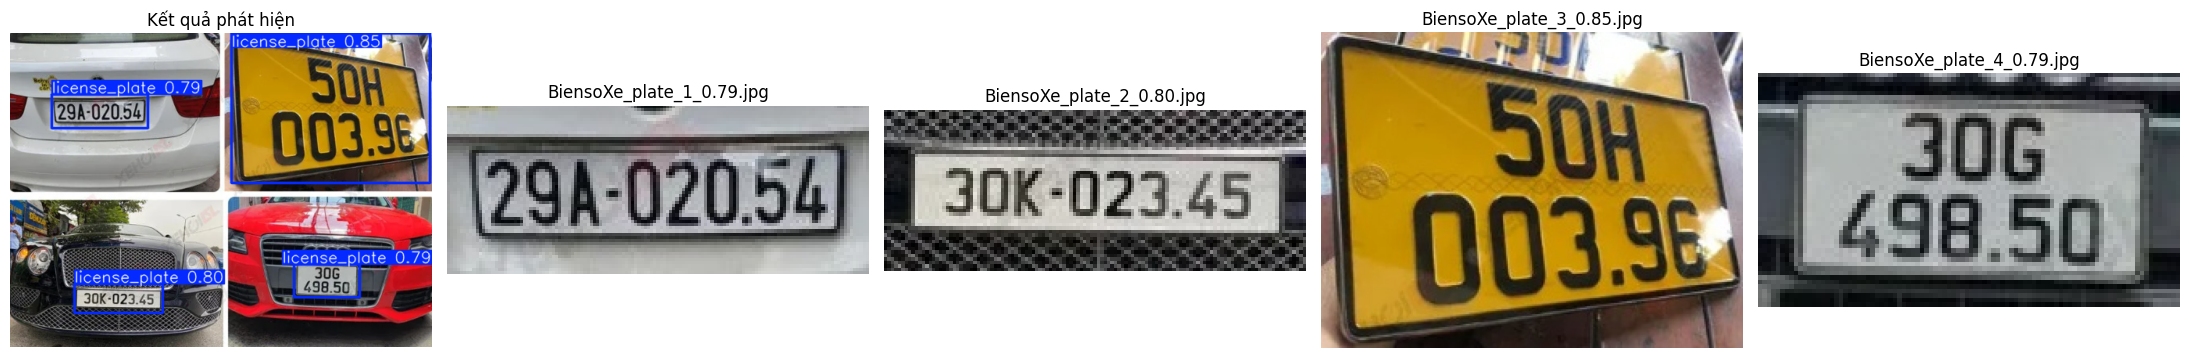

In [21]:
# Hiển thị ảnh có bounding box và các biển số đã cắt.
count = len(plate_paths)
fig, axes = plt.subplots(1, count + 1, figsize=(6 + 4 * count, 5))
axes = [axes] if count == 0 else axes

axes[0].imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
axes[0].set_title("Kết quả phát hiện")
axes[0].axis("off")

for ax, path in zip(axes[1:], plate_paths):
    plate = cv2.imread(str(path))
    ax.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Chuẩn bị PaddleOCR (Windows, Python 3.10)
Chạy cell cài đặt **một lần**, restart kernel, rồi mới chạy cell import. Bản CPU là lựa chọn ổn định để bắt đầu và có thể dùng cùng YOLO/PyTorch.

In [22]:
# Bỏ dấu # ở ba dòng dưới và chạy cell này một lần.
# %pip install -U pip
# %pip install paddlepaddle -i https://www.paddlepaddle.org.cn/packages/stable/cpu/
# %pip install paddleocr

# Sau khi cài xong: Kernel > Restart Kernel

In [23]:
# Chạy cell này sau khi đã restart kernel.
import paddle
from paddleocr import PaddleOCR

print("PaddlePaddle:", paddle.__version__)

# Biển số Việt Nam dùng ký tự Latin; tắt các module tài liệu không cần thiết.
ocr = PaddleOCR(
    lang="en",
    enable_mkldnn=False,  # Tránh lỗi oneDNN/PIR trên PaddlePaddle 3.3 Windows.
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
)

Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\vvvin\.paddlex\official_models\PP-OCRv6_medium_det`.


PaddlePaddle: 3.3.0


Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\vvvin\.paddlex\official_models\PP-OCRv6_medium_rec`.


BiensoXe_plate_1_0.79.jpg: 29A02054 (99.9%)
BiensoXe_plate_2_0.80.jpg: 30K02345 (100.0%)
BiensoXe_plate_3_0.85.jpg: 50H00396 (99.9%)
BiensoXe_plate_4_0.79.jpg: 30G49850 (99.6%)


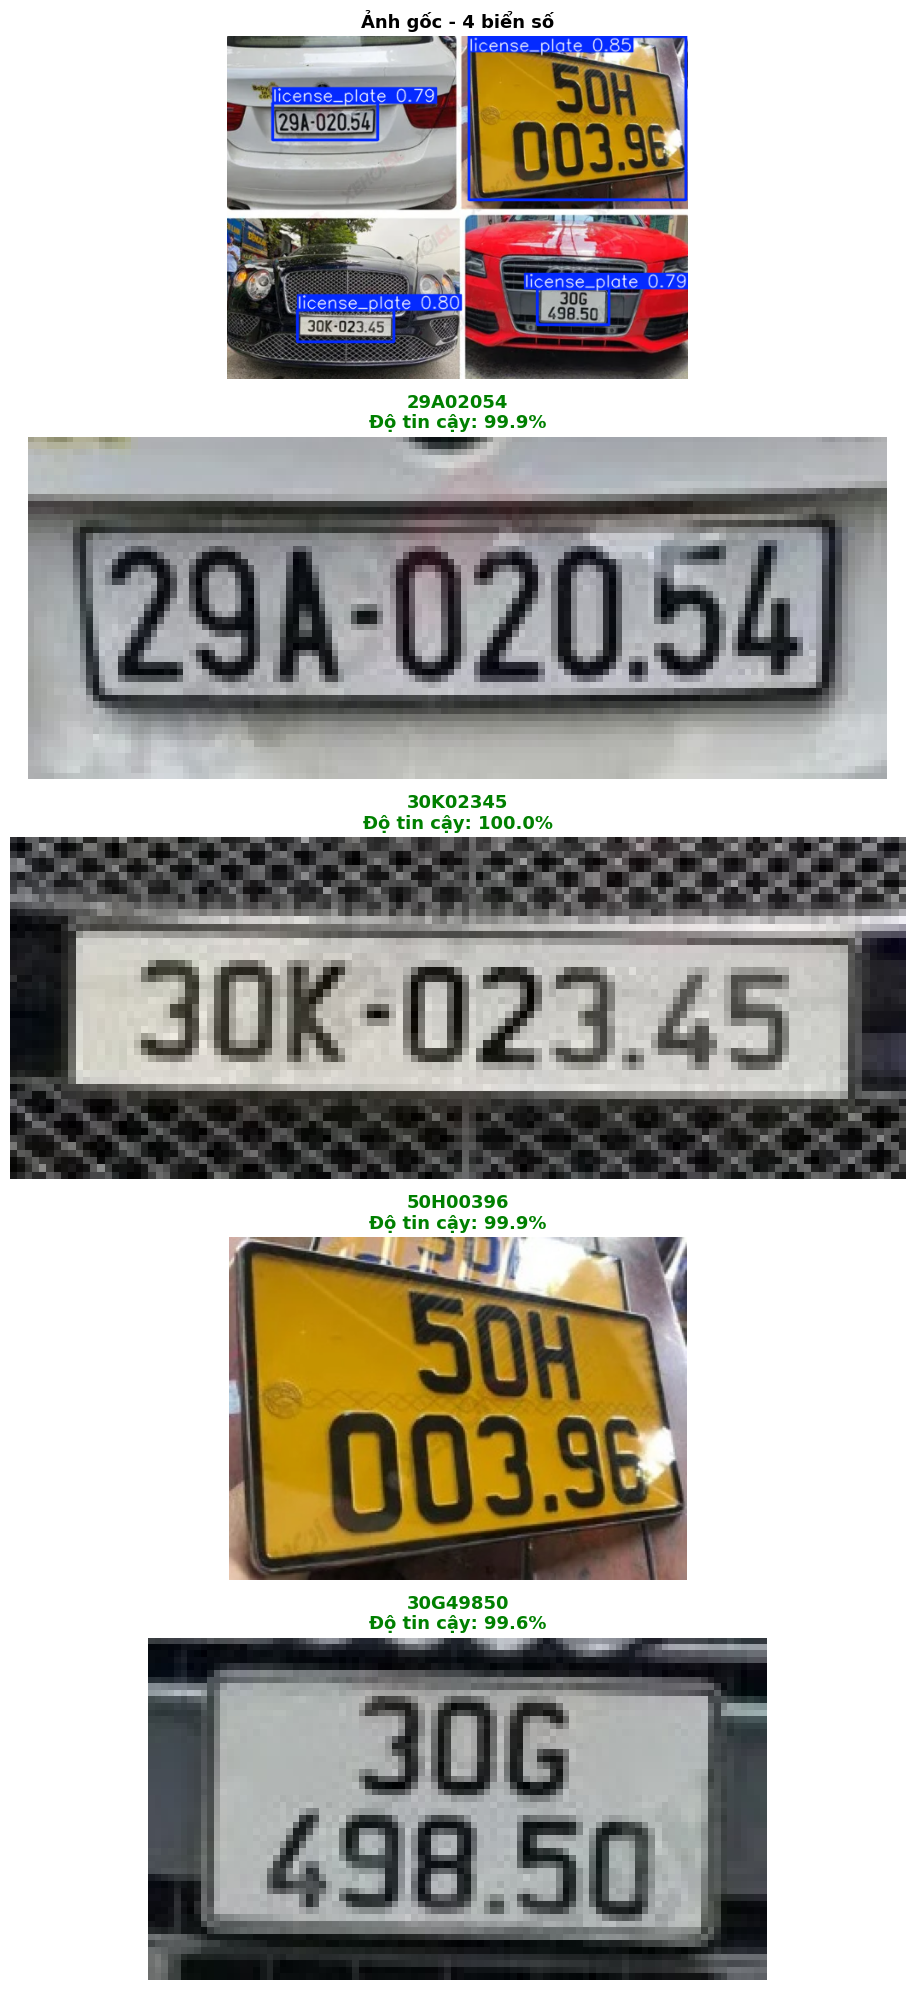

In [25]:
import re

def read_plate_text(image_path, min_score=0.30):
    """OCR một ảnh biển số đã cắt và trả về chuỗi đã chuẩn hóa."""
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")

    # Phóng lớn giúp OCR nhận ký tự trên biển số nhỏ ổn định hơn.
    image = cv2.resize(image, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    predictions = ocr.predict(input=image)
    candidates = []

    for prediction in predictions:
        data = getattr(prediction, "json", prediction)
        if callable(data):
            data = data()
        if isinstance(data, dict):
            data = data.get("res", data)
            texts = data.get("rec_texts", [])
            scores = data.get("rec_scores", [1.0] * len(texts))
            candidates.extend(
                (str(text), float(score))
                for text, score in zip(texts, scores)
                if float(score) >= min_score
            )

    # Giữ chữ và số, bỏ dấu cách/dấu chấm/gạch nối để tiện xử lý tiếp.
    plate_text = "".join(text for text, _ in candidates).upper()
    plate_text = re.sub(r"[^A-Z0-9]", "", plate_text)
    mean_score = (
        sum(score for _, score in candidates) / len(candidates)
        if candidates else 0.0
    )
    return plate_text, mean_score


ocr_results = []
for plate_path in plate_paths:
    text, score = read_plate_text(plate_path)
    ocr_results.append({"file": plate_path, "text": text, "score": score})
    print(f"{plate_path.name}: {text or '[không nhận dạng được]'} ({score:.1%})")

ocr_results

# Trực quan hóa ảnh detect, ảnh biển số đã cắt và kết quả OCR.
row_count = max(1, len(ocr_results)) + 1
fig, axes = plt.subplots(row_count, 1, figsize=(12, 4 * row_count))
axes = list(axes) if hasattr(axes, "__len__") else [axes]

axes[0].imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Ảnh gốc - {len(ocr_results)} biển số", fontsize=13, fontweight="bold")
axes[0].axis("off")

for ax, item in zip(axes[1:], ocr_results):
    plate = cv2.imread(str(item["file"]))
    ax.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
    label = item["text"] or "Không nhận dạng được"
    color = "green" if item["score"] >= 0.6 else "darkorange"
    ax.set_title(
        f"{label}\nĐộ tin cậy: {item['score']:.1%}",
        color=color, fontsize=13, fontweight="bold"
    )
    ax.axis("off")

# Nếu không detect được biển số, ẩn panel trống.
for ax in axes[1 + len(ocr_results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()